## Line chart with styles

1. Подключение к db.

In [7]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../data/checking-logs.sqlite")

2. Подготовка датафрейма views

In [8]:
query_pageviews = """
SELECT datetime
FROM pageviews
WHERE uid LIKE "user_%"
"""

views = pd.read_sql(query_pageviews, conn)
views["datetime"] = pd.to_datetime(views["datetime"])
views["date"] = views["datetime"].dt.date
views = views.groupby('date').size().reset_index(name='views').set_index("date")
views.head(10)

,views
date,
2020-04-17,1
2020-04-18,23
2020-04-19,15
2020-04-21,3
2020-04-22,1
2020-04-23,5
2020-04-25,1
2020-04-26,8
2020-04-28,2


3. Подготовка датафрейма commits.

In [9]:
query_commits = """
SELECT timestamp
FROM checker
WHERE uid LIKE "user_%"
AND labname IS NOT NULL
"""

commits = pd.read_sql(query_commits, conn)
commits["timestamp"] = pd.to_datetime(commits["timestamp"])
commits.rename(columns={'timestamp': 'date'}, inplace=True)
commits["date"] = commits["date"].dt.date
commits = commits.groupby('date').size().rename('commits').to_frame()

commits.head(10)

,commits
date,
2020-04-17,23
2020-04-18,69
2020-04-19,33
2020-04-20,24
2020-04-21,25
2020-04-22,27
2020-04-23,43
2020-04-24,16
2020-04-25,102


4. Построение графика

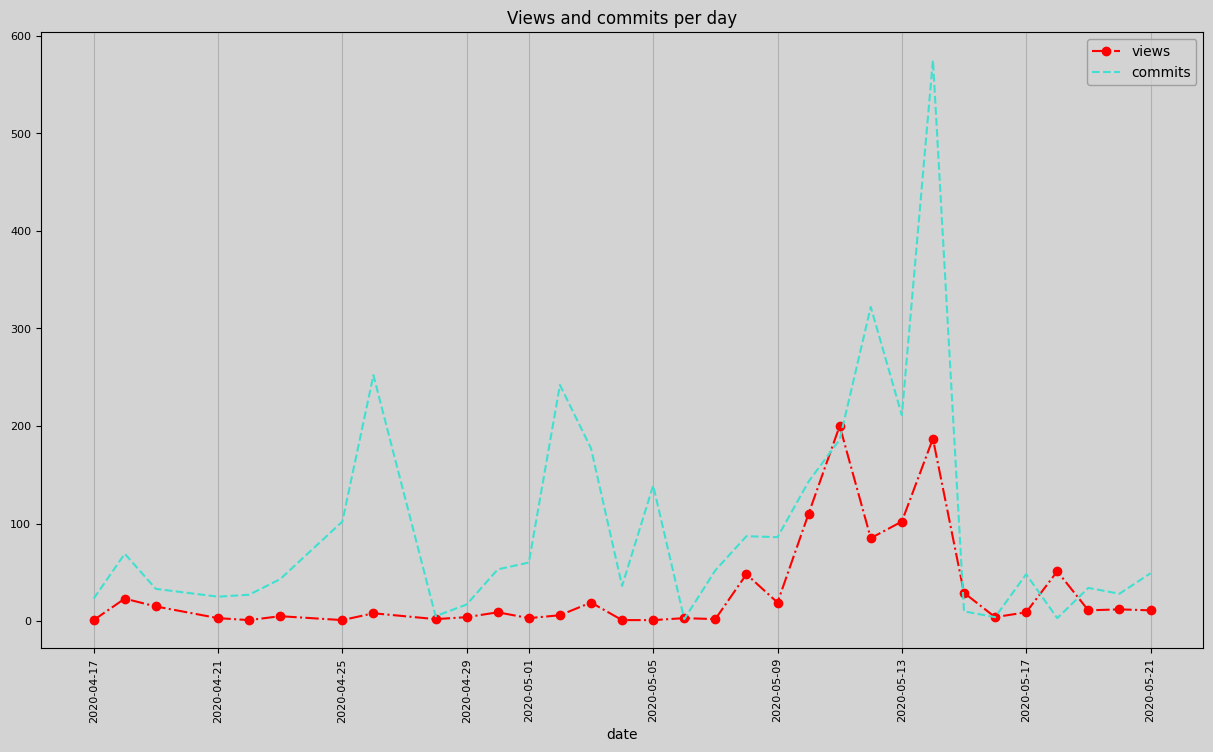

In [10]:
df_merge = pd.merge(views, commits, on="date", how="inner")

ax = df_merge.plot(
    figsize=(15, 8), 
    rot=90, 
    fontsize=8,
    title="Views and commits per day",
    xlabel="date"
    )

ax.grid(axis='x', )

ax.set_facecolor('#d3d3d3')
ax.figure.set_facecolor('#d3d3d3')

lines = ax.get_lines()

lines[0].set_color("red")
lines[0].set_linestyle("-.")
lines[0].set_marker("o")
lines[0].set_label("views")

lines[1].set_color("turquoise")
lines[1].set_linestyle("--")
lines[1].set_label("commits")

ax.legend(facecolor='lightgray', edgecolor="#939393")

In [11]:
conn.close()

Вопросы:

Сколько раз количество просмотров превышало 150?

In [ ]:
count = views[views["views"] > 150].count().item()

print(f"Ответ: {count}")

Ответ: 2


(32, 2)